In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('creditcard.csv')

print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
df.head()

Shape: (284807, 31)
Memory usage: 67.36 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [16]:
df = df.dropna()
missing = df[df.isnull().any(axis=1)].isnull().sum()
print("Total missing values:", missing.sum())

Total missing values: 0


In [17]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 1081


In [18]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_pct.round(4))

print(f"\nImbalance ratio (legit:fraud) = {class_counts[0] / class_counts[1]:.2f}:1")

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64

Imbalance ratio (legit:fraud) = 577.88:1


/tmp/ipykernel_458/3231171484.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_458/3231171484.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])


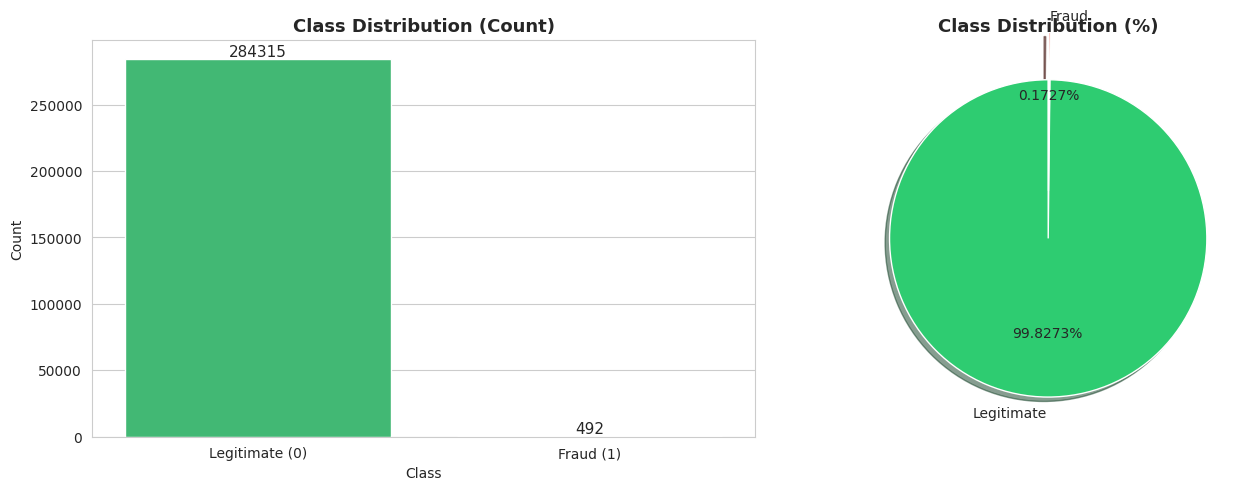

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x='Class', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'],
            autopct='%1.4f%%', colors=['#2ecc71', '#e74c3c'],
            explode=(0, 0.3), startangle=90, shadow=True)
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

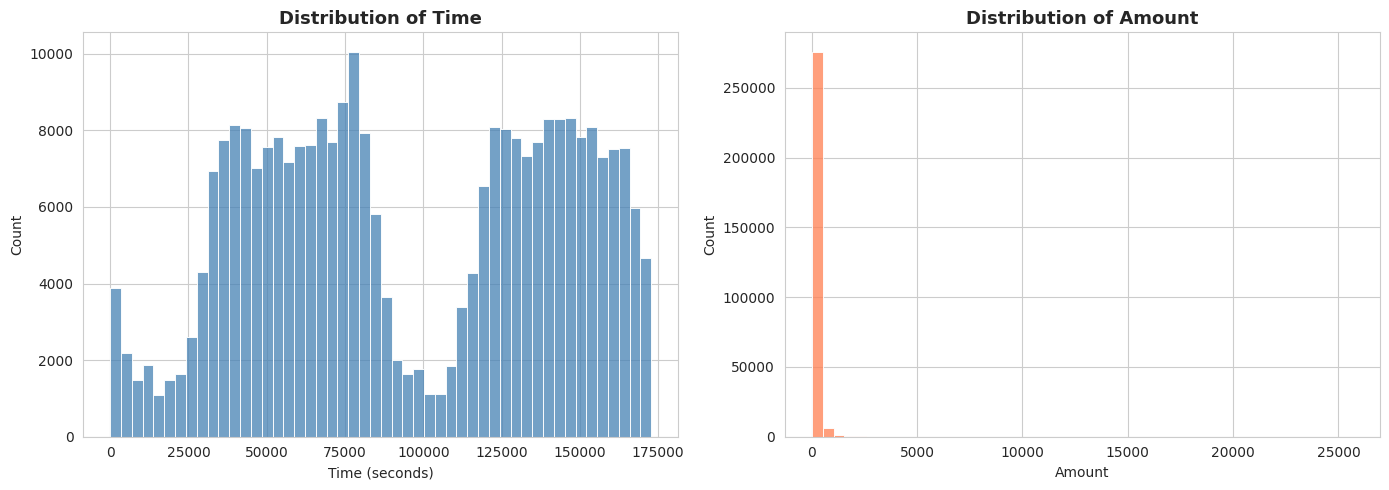

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Time'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time (seconds)')

sns.histplot(df['Amount'], bins=50, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Amount', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()

/tmp/ipykernel_458/2039182900.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_458/2039182900.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate', 'Fraud'])
/tmp/ipykernel_458/2039182900.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Time', data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_458/2039182900.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axe

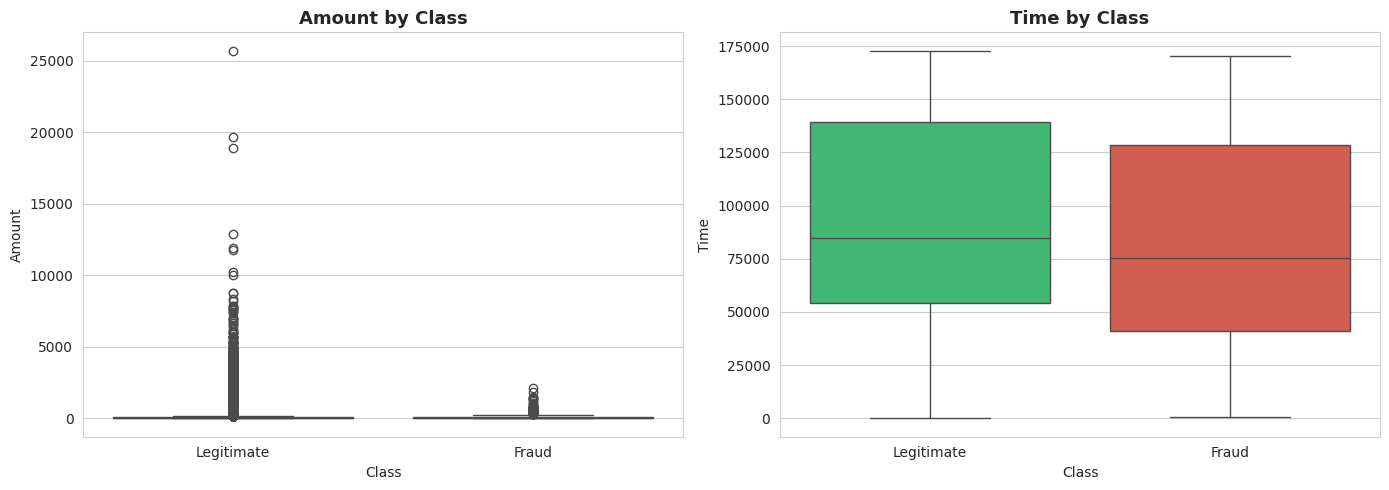

Amount statistics by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Amount by Class', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])

sns.boxplot(x='Class', y='Time', data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Time by Class', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

# Summary stats
print("Amount statistics by class:")
print(df.groupby('Class')['Amount'].describe())

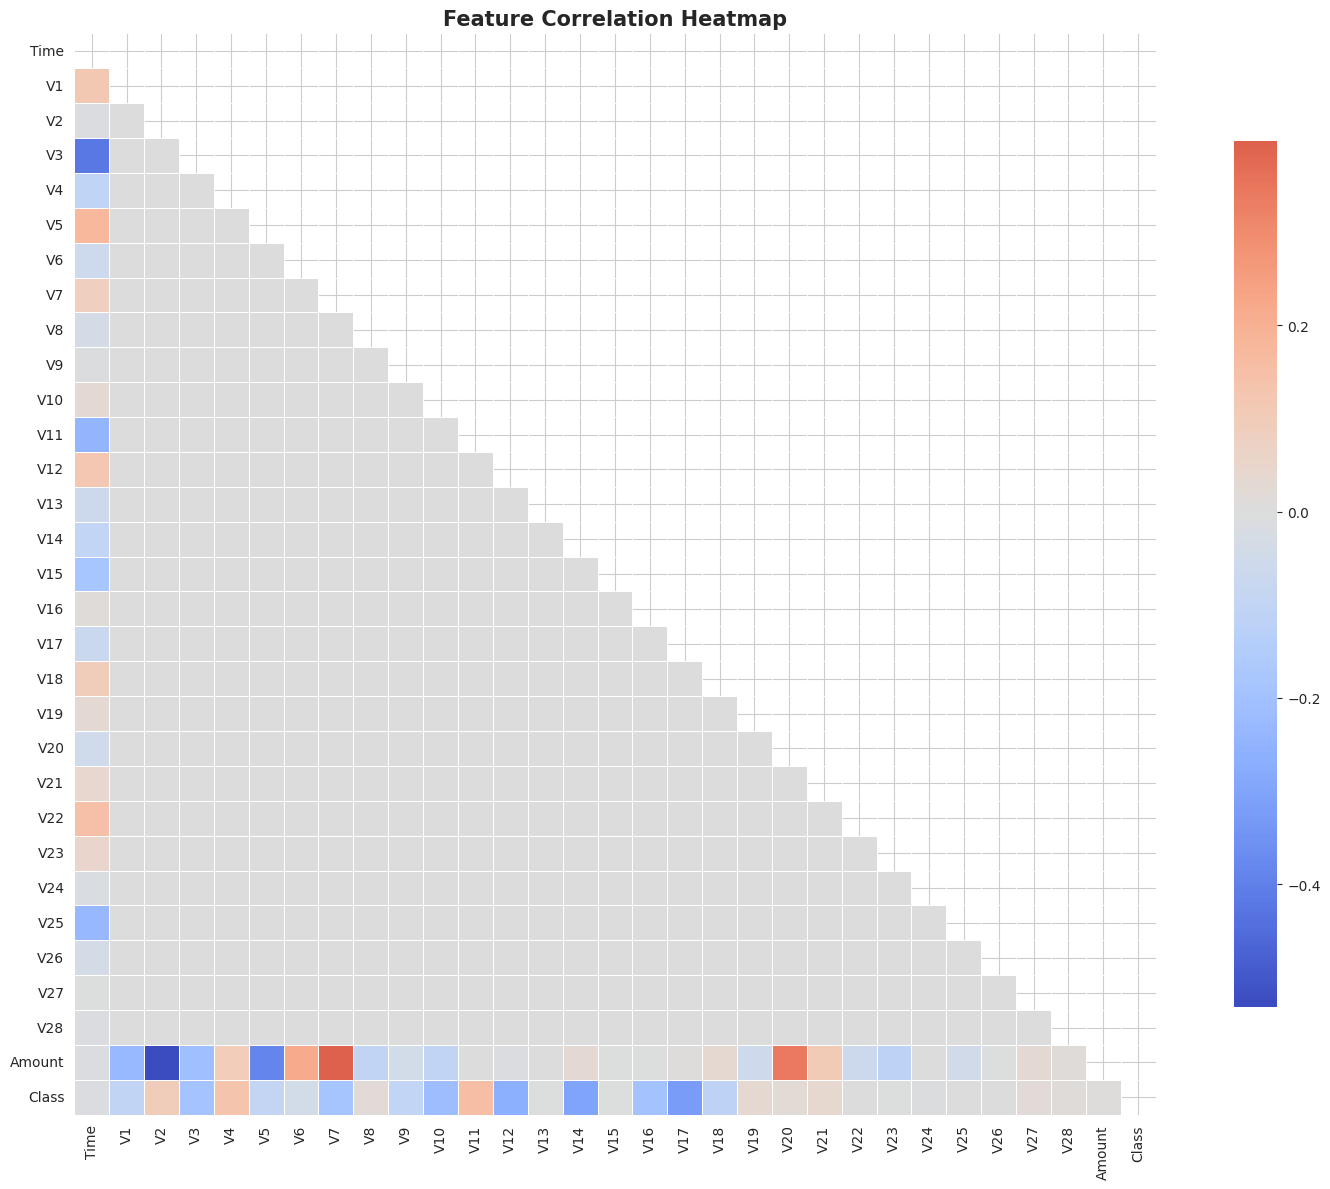

In [22]:
plt.figure(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

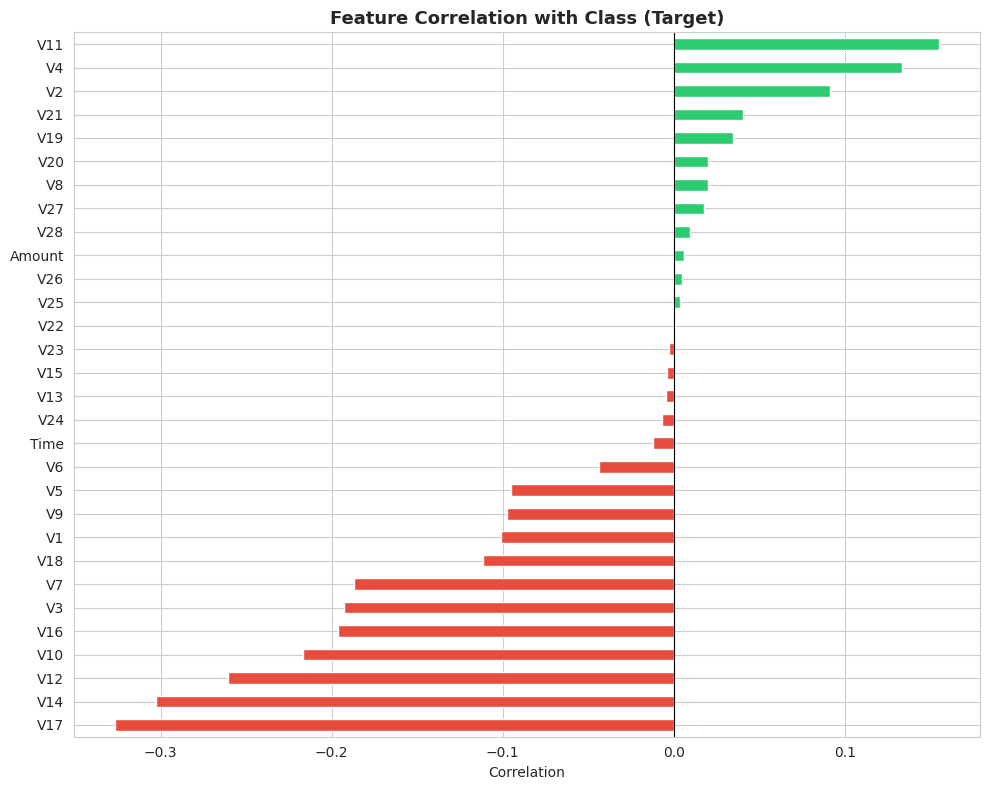

Top 10 most negatively correlated with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64

Top 10 most positively correlated with fraud:
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Name: Class, dtype: float64


In [23]:
corr_with_class = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 8))
corr_with_class.plot(kind='barh', color=['#e74c3c' if x < 0 else '#2ecc71' for x in corr_with_class])
plt.title('Feature Correlation with Class (Target)', fontsize=13, fontweight='bold')
plt.xlabel('Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Top 10 most negatively correlated with fraud:")
print(corr_with_class.head(10))
print("\nTop 10 most positively correlated with fraud:")
print(corr_with_class.tail(10))

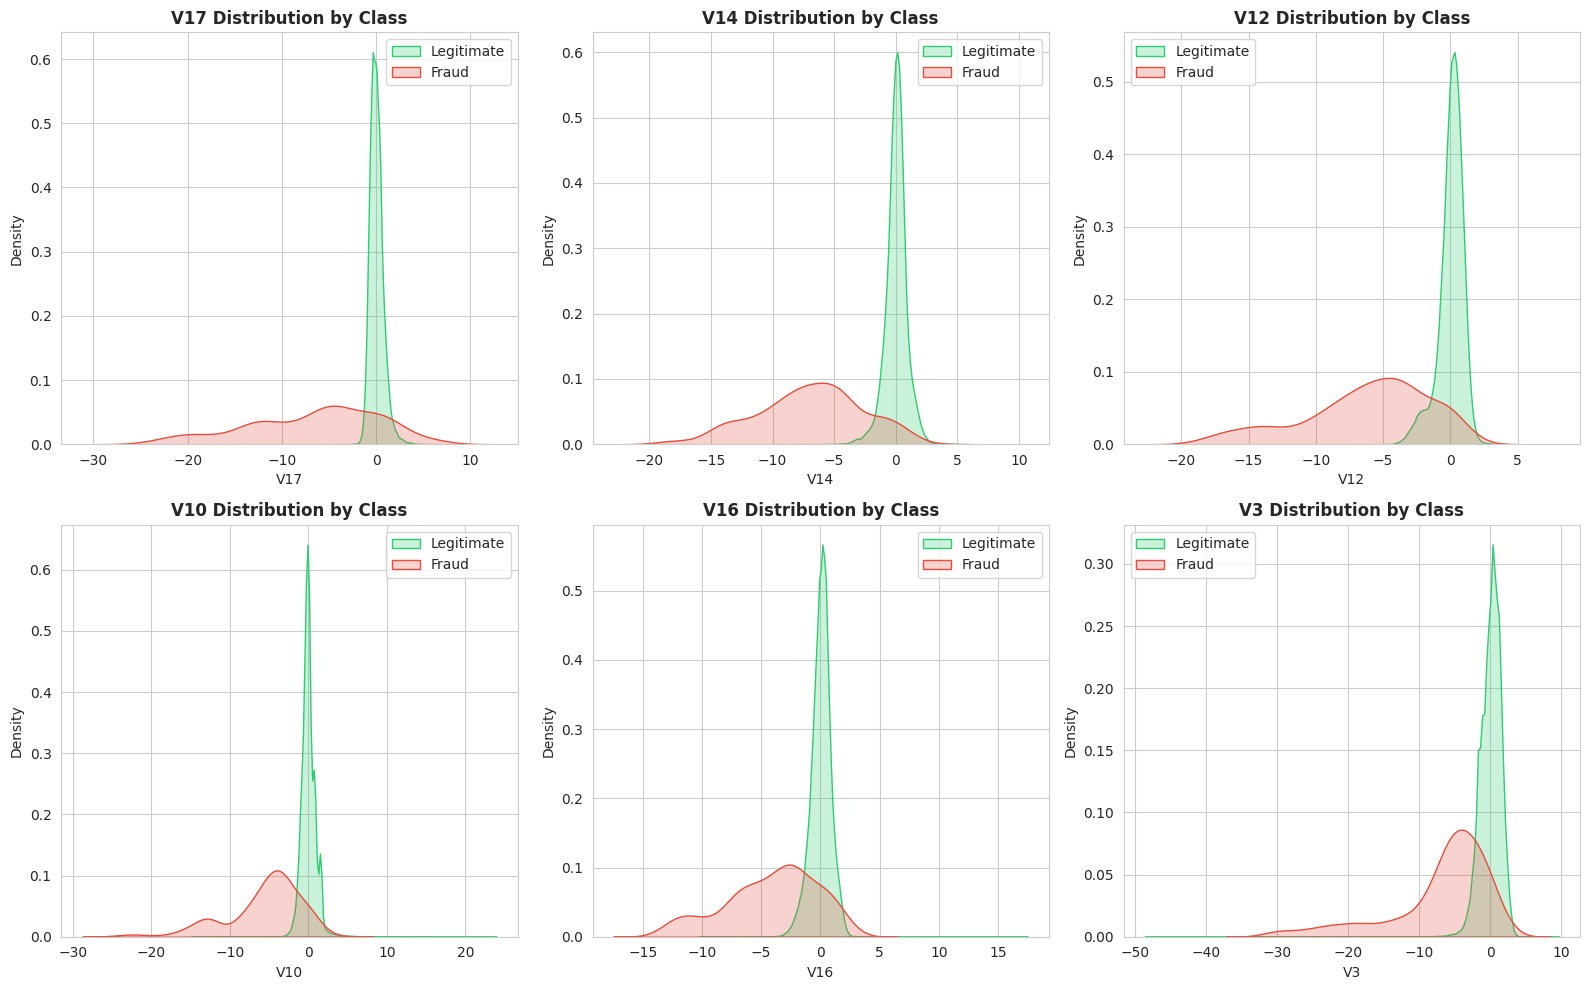

In [24]:
top_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.kdeplot(df[df['Class']==0][feat], ax=axes[i], label='Legitimate', fill=True, color='#2ecc71')
    sns.kdeplot(df[df['Class']==1][feat], ax=axes[i], label='Fraud', fill=True, color='#e74c3c')
    axes[i].set_title(f'{feat} Distribution by Class', fontweight='bold')
    axes[i].legend()

plt.tight_layout()
plt.show()